# Exploratory Data Analysis with SQL

## Importing Libraries

In [26]:
import numpy as np # linear algebra
import pandas as pd # data processing

import seaborn as sns #statist graph package
import matplotlib.pyplot as plt #plot package
import pandasql as ps #sql package

plt.style.use('bmh')

# Reading the dataset

In [27]:
df = pd.read_csv('dataisbeautiful_posts.csv', low_memory=False)
df

,id,title,score,author,author_flair_text,removed_by,total_awards_received,awarders,created_utc,full_link,num_comments,over_18
0,ll1p9h,Wordcloud of trending video titles on YouTube ...,1,OmarZiada,OC: 1,NaN,0.0,[],1613473961,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
1,ll1o4h,Wordcloud of trending videos on YouTube in the...,1,OmarZiada,OC: 1,moderator,0.0,[],1613473829,https://www.reddit.com/r/dataisbeautiful/comme...,1,False
2,ll15gx,Immunization in India. Source: https://niti.go...,1,Professional_Napper_,NaN,moderator,0.0,[],1613471541,https://www.reddit.com/r/dataisbeautiful/comme...,1,False
3,ll0iup,How to quickly estimate the impact of players ...,1,Viziball,NaN,automod_filtered,0.0,[],1613468624,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
4,ll0g9a,How to quickly estimate the impact of players ...,1,Viziball,NaN,moderator,0.0,[],1613468281,https://www.reddit.com/r/dataisbeautiful/comme...,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...
190848,pqbdl,Infosthetics seems like it belongs here.,15,magiclamp,NaN,NaN,NaN,NaN,1329282849,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
190849,pqav2,Time lapse of every nuclear detonation from 19...,9,th3sousa,NaN,NaN,NaN,NaN,1329282160,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
190850,pq922,Wavii.,13,ddshroom,NaN,NaN,NaN,NaN,1329279777,https://www.reddit.com/r/dataisbeautiful/comme...,2,False
190851,ppx09,An interactive representation of Pres. Obamas ...,21,zanycaswell,NaN,NaN,NaN,NaN,1329265203,https://www.reddit.com/r/dataisbeautiful/comme...,0,False


In [28]:
df.sample(5)

,id,title,score,author,author_flair_text,removed_by,total_awards_received,awarders,created_utc,full_link,num_comments,over_18
58254,cifp08,Buy Negative Google Reviews - Buy Bad &amp; 1 ...,1,nur1236,NaN,NaN,0.0,NaN,1564221188,https://www.reddit.com/r/dataisbeautiful/comme...,1,False
186444,1g6v2b,"""Dear NSA, you can do whatever you want with m...",0,lordrandom12,NaN,NaN,NaN,NaN,1371038286,https://www.reddit.com/r/dataisbeautiful/comme...,1,False
22153,h0re21,[OC] Rage Against The Machine - Rage Against T...,6,[deleted],NaN,deleted,0.0,[],1591847039,https://www.reddit.com/r/dataisbeautiful/comme...,2,False
44873,eod54b,[OC] Metacritic Scores for the Skywalker Saga ...,1,EquiNox127,NaN,NaN,0.0,[],1578961483,https://www.reddit.com/r/dataisbeautiful/comme...,3,False
12849,in29im,[OC] The Umbrella Academy character screen time!,1,Voose200,NaN,NaN,0.0,[],1599317048,https://www.reddit.com/r/dataisbeautiful/comme...,3,False


In [29]:
df.head(5)

,id,title,score,author,author_flair_text,removed_by,total_awards_received,awarders,created_utc,full_link,num_comments,over_18
0,ll1p9h,Wordcloud of trending video titles on YouTube ...,1,OmarZiada,OC: 1,NaN,0.0,[],1613473961,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
1,ll1o4h,Wordcloud of trending videos on YouTube in the...,1,OmarZiada,OC: 1,moderator,0.0,[],1613473829,https://www.reddit.com/r/dataisbeautiful/comme...,1,False
2,ll15gx,Immunization in India. Source: https://niti.go...,1,Professional_Napper_,NaN,moderator,0.0,[],1613471541,https://www.reddit.com/r/dataisbeautiful/comme...,1,False
3,ll0iup,How to quickly estimate the impact of players ...,1,Viziball,NaN,automod_filtered,0.0,[],1613468624,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
4,ll0g9a,How to quickly estimate the impact of players ...,1,Viziball,NaN,moderator,0.0,[],1613468281,https://www.reddit.com/r/dataisbeautiful/comme...,2,False


In [30]:
df.tail(5)

,id,title,score,author,author_flair_text,removed_by,total_awards_received,awarders,created_utc,full_link,num_comments,over_18
190848,pqbdl,Infosthetics seems like it belongs here.,15,magiclamp,NaN,NaN,NaN,NaN,1329282849,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
190849,pqav2,Time lapse of every nuclear detonation from 19...,9,th3sousa,NaN,NaN,NaN,NaN,1329282160,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
190850,pq922,Wavii.,13,ddshroom,NaN,NaN,NaN,NaN,1329279777,https://www.reddit.com/r/dataisbeautiful/comme...,2,False
190851,ppx09,An interactive representation of Pres. Obamas ...,21,zanycaswell,NaN,NaN,NaN,NaN,1329265203,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
190852,ppvl7,A map showing the geographical distribution of...,45,zanycaswell,NaN,NaN,NaN,NaN,1329263456,https://www.reddit.com/r/dataisbeautiful/comme...,5,False


In [31]:
print("Data shape: ", df.shape)

Data shape:  (190853, 12)


## Getting a feel of the dataset

Let's run basic dataframe exploratory commands

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 190853 entries, 0 to 190852
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     190853 non-null  str    
 1   title                  190852 non-null  str    
 2   score                  190853 non-null  int64  
 3   author                 190853 non-null  str    
 4   author_flair_text      28845 non-null   str    
 5   removed_by             20744 non-null   str    
 6   total_awards_received  65146 non-null   float64
 7   awarders               54478 non-null   str    
 8   created_utc            190853 non-null  int64  
 9   full_link              190853 non-null  str    
 10  num_comments           190853 non-null  int64  
 11  over_18                190853 non-null  bool   
dtypes: bool(1), float64(1), int64(3), str(7)
memory usage: 16.2 MB


In [33]:
df.describe()

,score,total_awards_received,created_utc,num_comments
count,190853.000000,65146.000000,1.908530e+05,190853.000000
mean,176.016159,0.013109,1.512494e+09,27.604732
std,1951.936524,0.589425,6.822624e+07,213.236378
min,0.000000,0.000000,1.329263e+09,0.000000
25%,1.000000,0.000000,1.463862e+09,1.000000
50%,1.000000,0.000000,1.518662e+09,2.000000
75%,4.000000,0.000000,1.576576e+09,5.000000
max,116226.000000,93.000000,1.613474e+09,18801.000000


In [34]:
df.isnull().sum().sort_values(ascending=False)

removed_by               170109
author_flair_text        162008
awarders                 136375
total_awards_received    125707
title                         1
author                        0
id                            0
score                         0
created_utc                   0
full_link                     0
num_comments                  0
over_18                       0
dtype: int64

## Removed data

In [35]:
q1 = """SELECT
            removed_by,
            COUNT(distinct id) as number_of_removed_posts
        FROM df
        WHERE removed_by IS NOT NULL
        GROUP BY removed_by
        ORDER BY 2 DESC"""

grouped_df = ps.sqldf(q1, locals())
grouped_df

,removed_by,number_of_removed_posts
0,moderator,14789
1,deleted,2948
2,automod_filtered,1553
3,reddit,1453
4,author,1


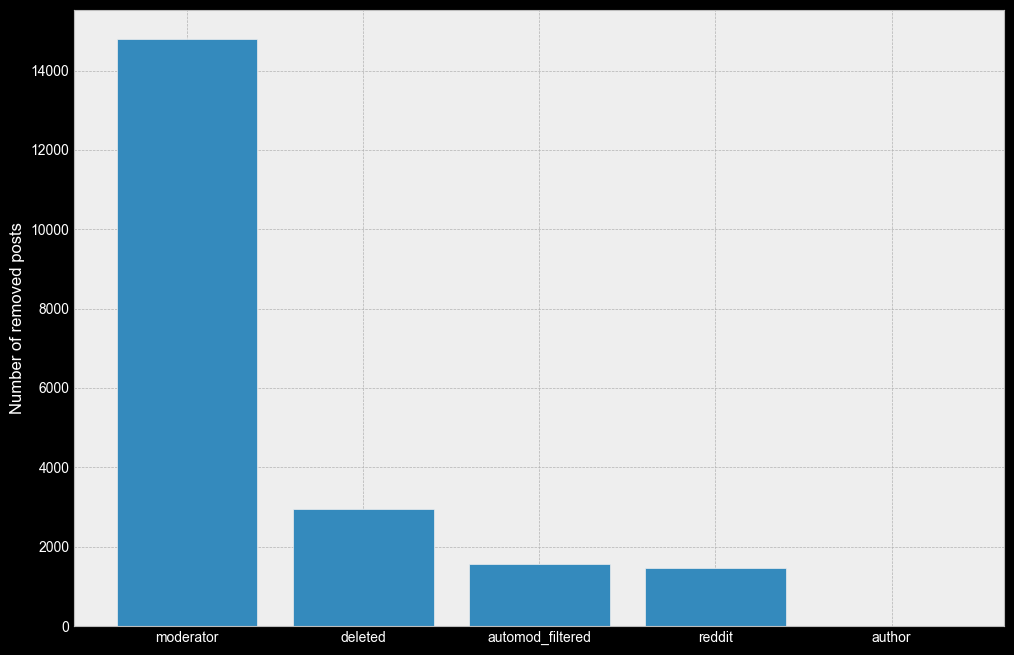

In [36]:
removed_by = grouped_df['removed_by'].tolist()
number_of_removed_posts  = grouped_df['number_of_removed_posts'].tolist()

plt.figure(figsize=(12,8))
plt.ylabel('Number of removed posts')
plt.bar(removed_by, number_of_removed_posts)

plt.show()

In [37]:
q2 = """
    SELECT
        author, COUNT(id) as number_of_removed_posts
    FROM df
    where removed_by = 'moderator'
    group by author
    order by 2 DESC
    LIMIT 3
"""

print(ps.sqldf(q2, locals()))

           author  number_of_removed_posts
0    hornedviper9                       71
1  peter_mladenov                       35
2     ad55mul1994                       20


In [46]:
q3 = """
    with Virus as (
        SELECT
            id
        FROM df
        WHERE removed_by = 'moderator'
        AND
        title like '%virus%'
    )

    SELECT
        COUNT(v.id) AS virus_removed,
        count(d.id) AS all_removed
    FROM df AS d
    LEFT JOIN virus AS v ON v.id = d.id
    WHERE d.removed_by = 'moderator'
"""

removed_moderator_df = ps.sqldf(q3, locals())

print(removed_moderator_df.values)
print(removed_moderator_df.values[0])

[[ 1056 14789]]
[ 1056 14789]


In [41]:
virus_removed_id = removed_moderator_df.values[0][0]
all_removed_id = removed_moderator_df.values[0][1]

print(virus_removed_id / all_removed_id)

0.07140442220569342


## Most popular reddits

In [47]:
q4 = """
    SELECT
        title,
        num_comments AS number_of_comments
    FROM df
    WHERE title != 'data_irl'
    ORDER BY num_comments DESC
    LIMIT 10
"""

print(ps.sqldf(q4, locals()))

                                               title  number_of_comments
0  The best (&amp; worst) countries for raising a...               12508
1            Police killing rates in G7 members [OC]               10425
2  [oc] How taboo and popular are sexual fetishes...               10396
3  Worst Episode Ever? The Most Commonly Rated Sh...                9217
4  The environmental impact of Beyond Meat and a ...                9120
5               What's getting cut in Trump's budget                8768
6      [OC] Mississippi, the Poorest State in the US                8703
7  [OC] Trump voters are less likely to have a co...                8354
8  [OC] Trending Google Searches by State Between...                8270
9  Almost all men are stronger than almost all wo...                7538


## The most common words